In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
data = pd.read_excel("/content/data.xlsx", sheet_name = "E Comm" )

In [ ]:
data.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

Tenure: Tenure of a customer in the company (numeric)

WarehouseToHome: Distance between the warehouse to the customer's home (numeric)

NumberOfDeviceRegistered: Total number of devices registered to a particular customer (numeric)

PreferedOrderCat: Preferred order category of a customer in the last month (categorical)

SatisfactionScore: Satisfactory score of a customer on service (numeric)

MaritalStatus: Marital status of a customer (categorical)


NumberOfAddress: Total number of addresses added for a particular customer (numeric)

Complaint: Whether any complaint has been raised in the last month (binary)

DaySinceLastOrder: Days since last order by customer (numeric)

CashbackAmount: Average cashback in last month (numeric)

Churn: Churn flag (target variable, binary)

In [ ]:
data.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
data.shape

(5630, 20)

In [ ]:
missing_percent = data.isnull().mean() * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

DaySinceLastOrder              5.452931
OrderAmountHikeFromlastYear    4.706927
Tenure                         4.689165
OrderCount                     4.582593
CouponUsed                     4.547069
HourSpendOnApp                 4.529307
WarehouseToHome                4.458259
dtype: float64


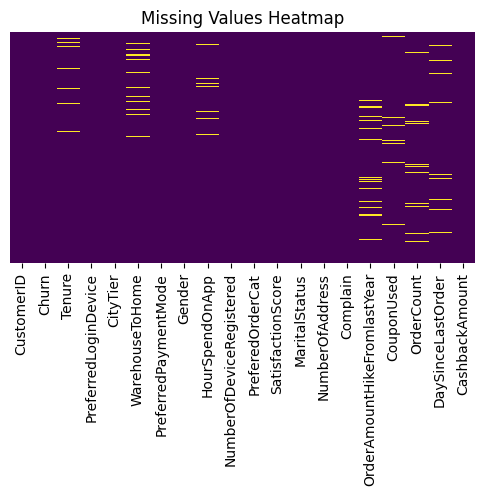

In [ ]:
plt.figure(figsize=(6, 3))
sns.heatmap(data.isnull(), cmap='viridis',cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
columns = ['Tenure', 'WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

for col in columns:
    skew_val = data[col].skew()
    print(f"Skewness of {col}: {skew_val:.2f}")


Skewness of Tenure: 0.74
Skewness of WarehouseToHome: 1.62
Skewness of HourSpendOnApp: -0.03
Skewness of OrderAmountHikeFromlastYear: 0.79
Skewness of CouponUsed: 2.55
Skewness of OrderCount: 2.20
Skewness of DaySinceLastOrder: 1.19
Skewness of CashbackAmount: 1.15


In [ ]:
# Median Imputation for Highly Skewed
cols_median = ['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear',
               'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

for col in cols_median:
    data[col] = data[col].fillna(data[col].median())

# Mean Imputation for Near Symmetric
data['HourSpendOnApp'] = data['HourSpendOnApp'].fillna(data['HourSpendOnApp'].mean())

In [ ]:
missing_percent = data.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

CustomerID                     0.0
Churn                          0.0
Tenure                         0.0
PreferredLoginDevice           0.0
CityTier                       0.0
WarehouseToHome                0.0
PreferredPaymentMode           0.0
Gender                         0.0
HourSpendOnApp                 0.0
NumberOfDeviceRegistered       0.0
PreferedOrderCat               0.0
SatisfactionScore              0.0
MaritalStatus                  0.0
NumberOfAddress                0.0
Complain                       0.0
OrderAmountHikeFromlastYear    0.0
CouponUsed                     0.0
OrderCount                     0.0
DaySinceLastOrder              0.0
CashbackAmount                 0.0
dtype: float64


In [ ]:
duplicate_customer_ids = data.duplicated(subset=['CustomerID'])
num_duplicates = duplicate_customer_ids.sum()
print(f"Number of repeated customer IDs: {num_duplicates}")

Number of repeated customer IDs: 0


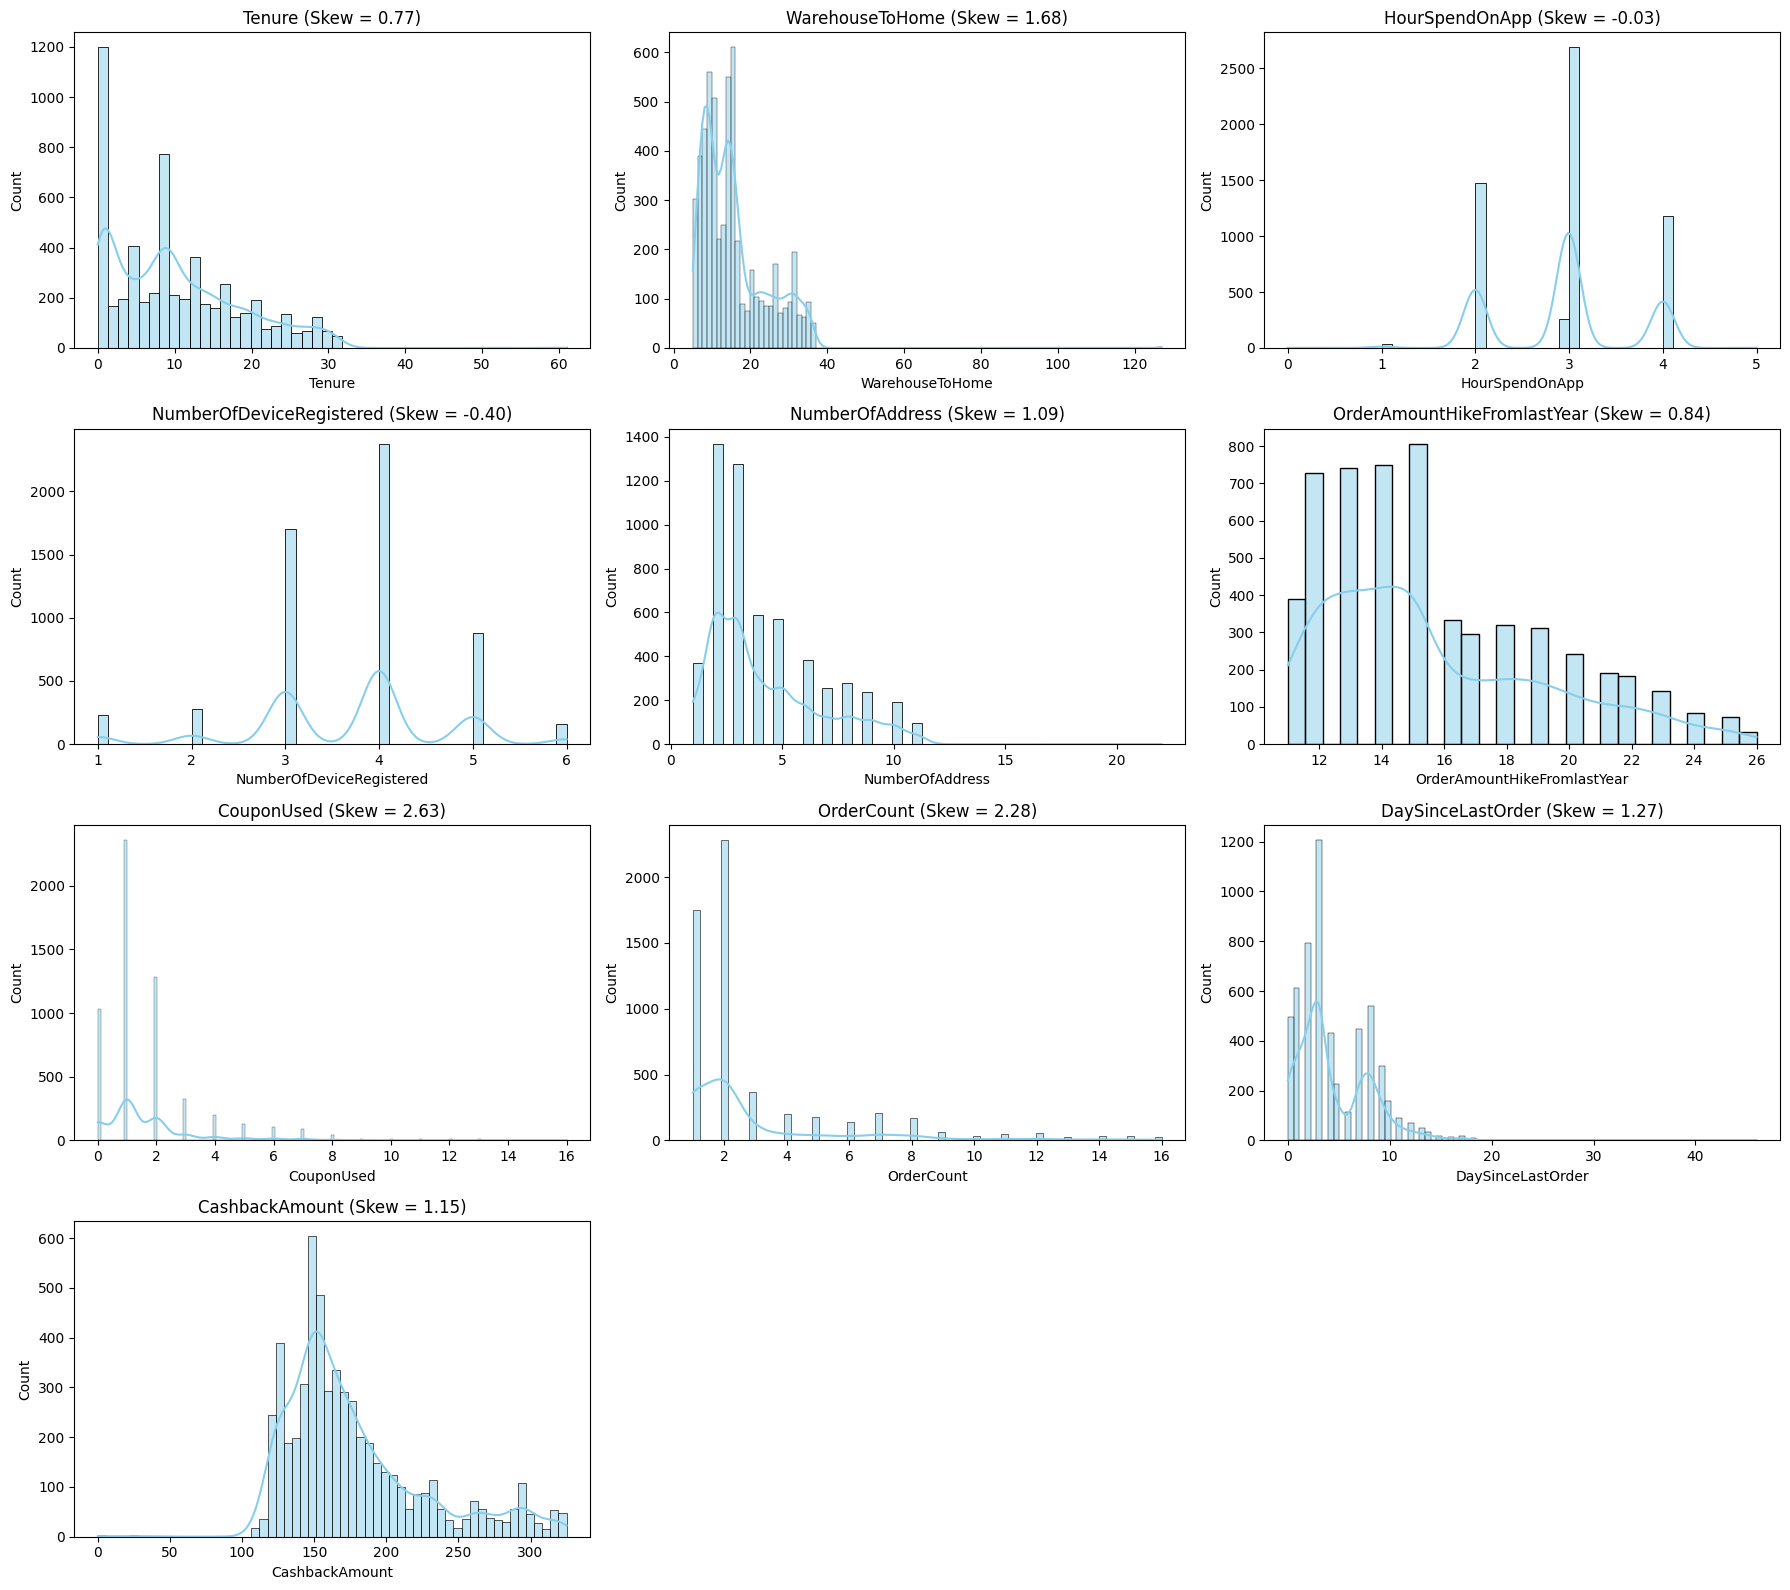

In [ ]:
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'NumberOfAddress', 'OrderAmountHikeFromlastYear',
            'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

# 4 x 3 grid (10 plots)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"{col} (Skew = {data[col].skew():.2f})")

# Hide any unused subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

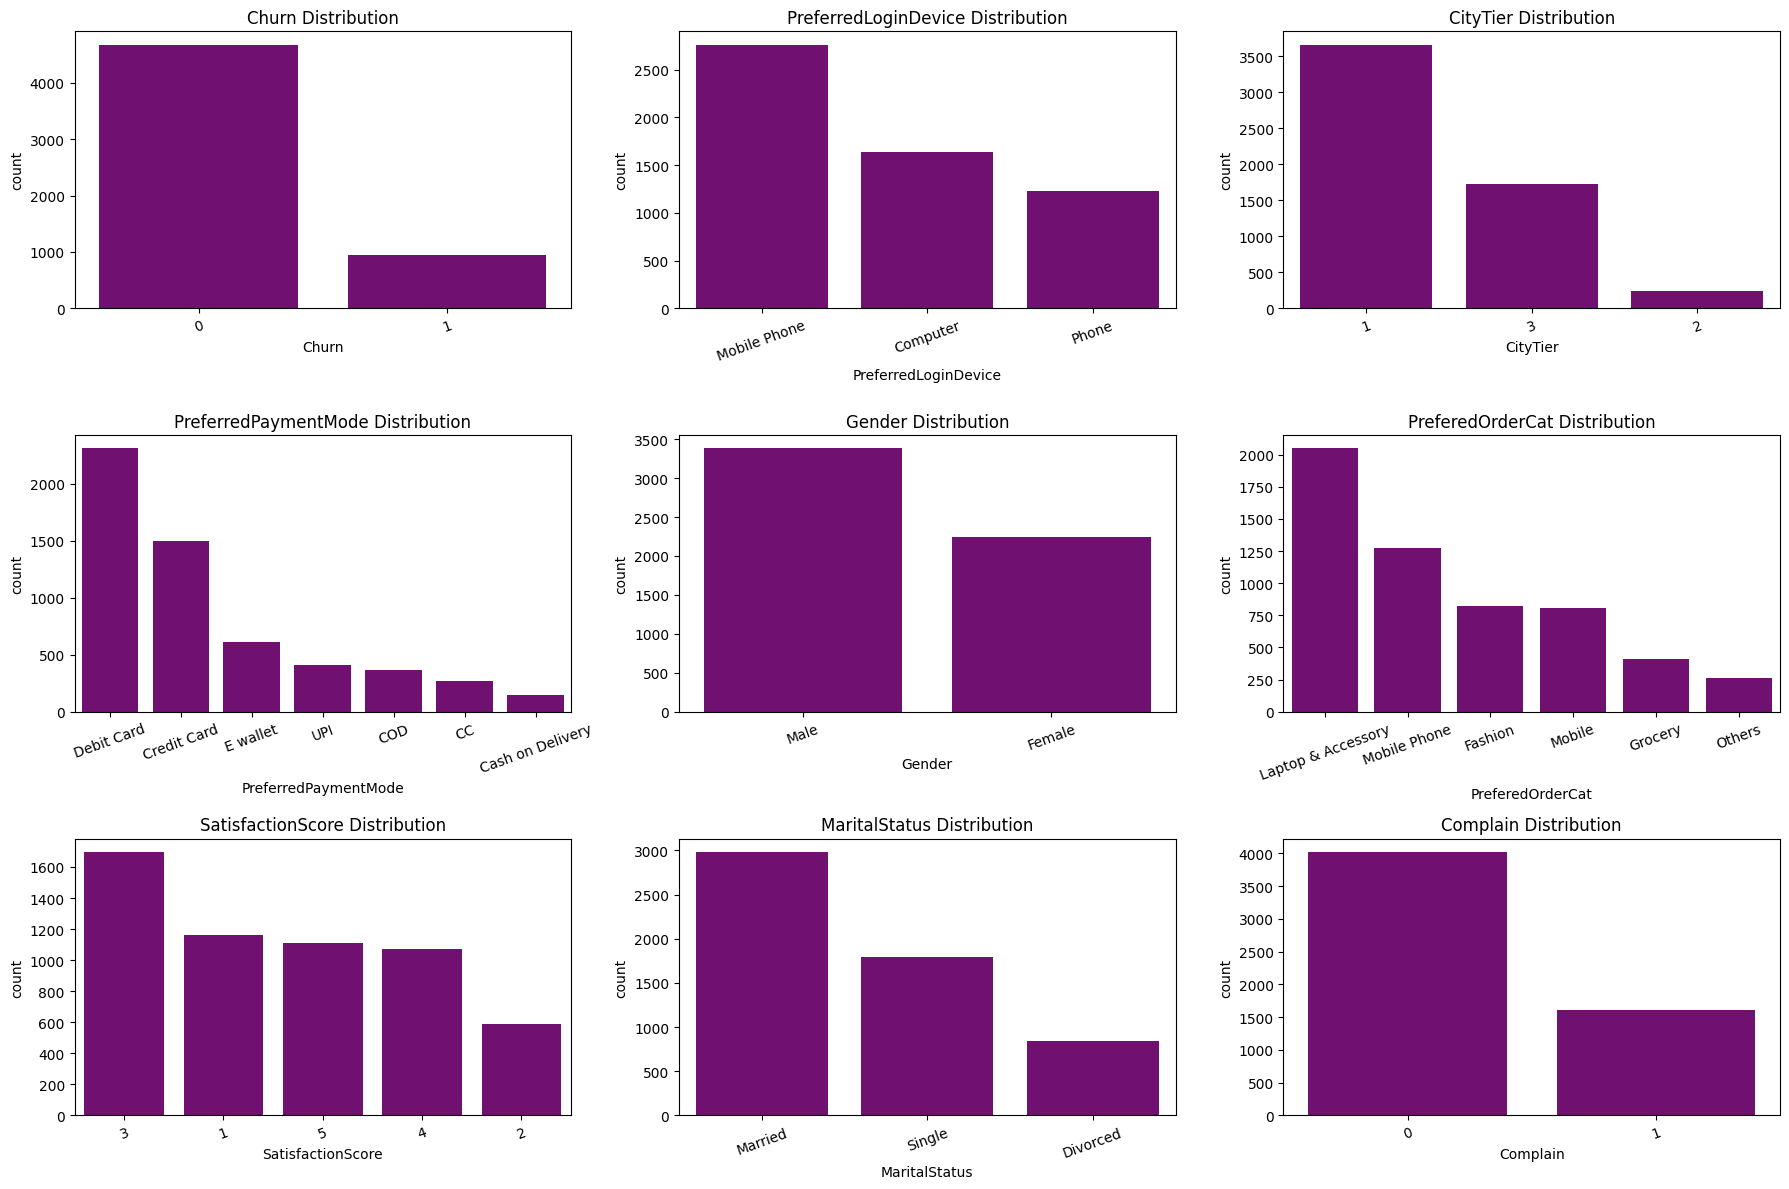

In [ ]:
cat_cols = ['Churn', 'PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'SatisfactionScore',
            'MaritalStatus', 'Complain']

# Set up 3 x 3 subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, ax=axes[i], color = "purple")
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation= 20)

plt.tight_layout()
plt.show()

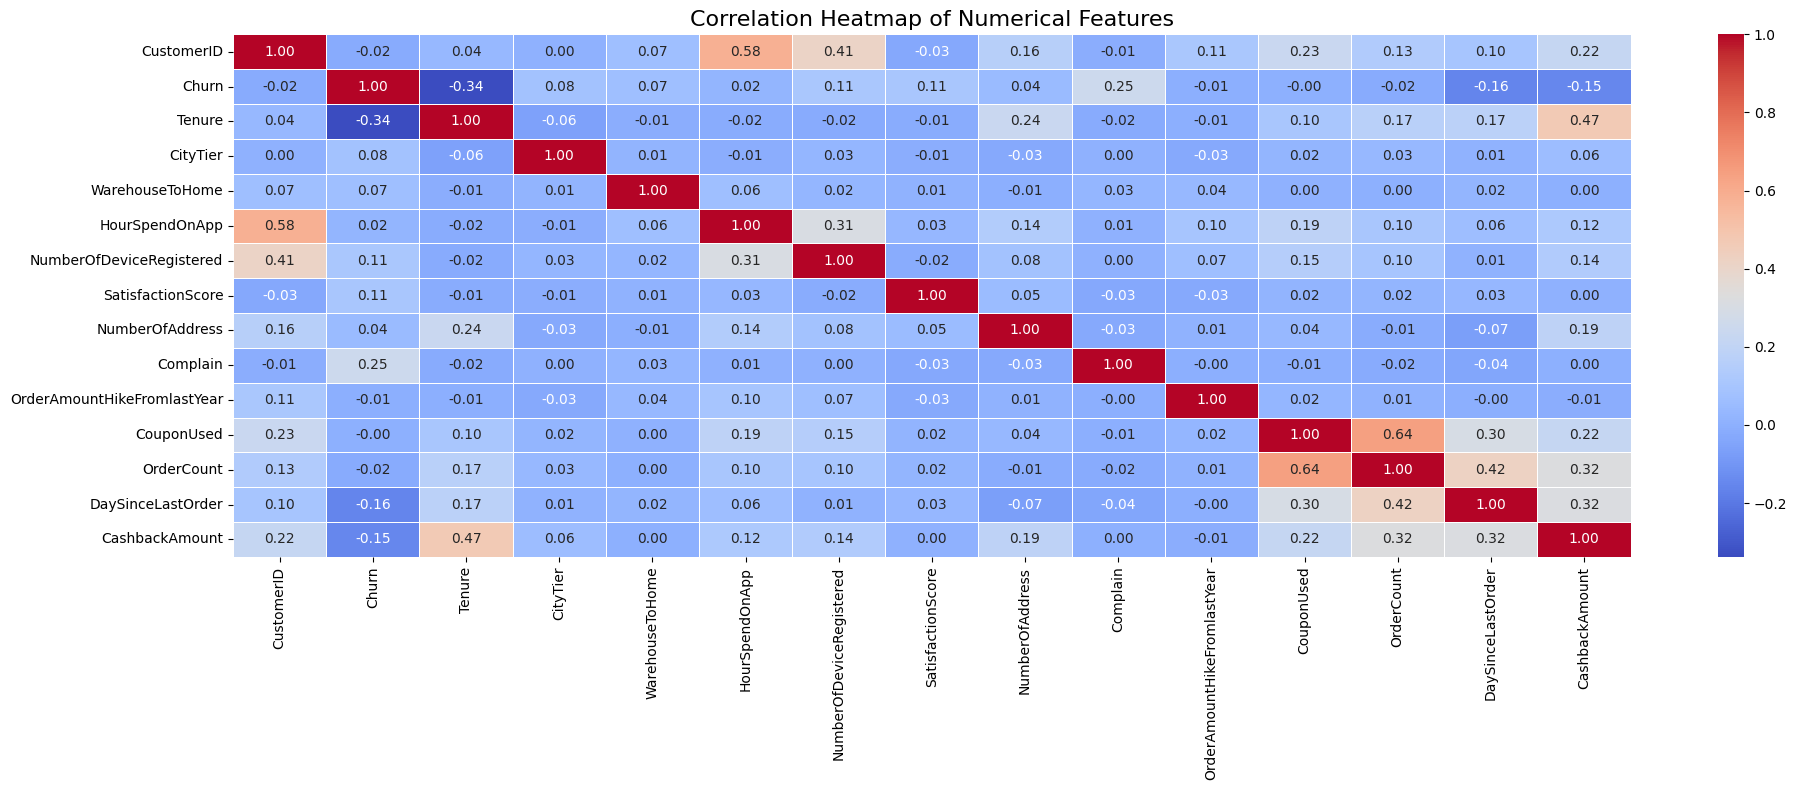

In [ ]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

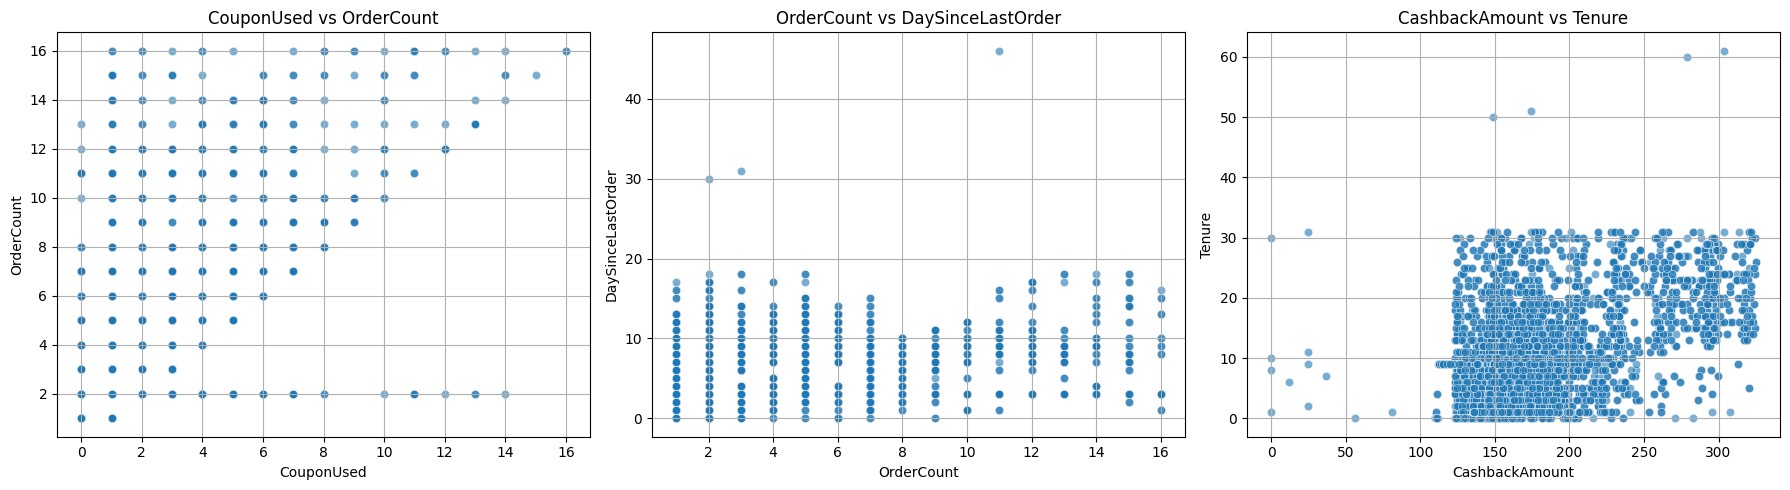

In [ ]:
feature_pairs = [
    ('CouponUsed', 'OrderCount'),
    ('OrderCount', 'DaySinceLastOrder'),
    ('CashbackAmount', 'Tenure')
]

# Create 1 row, 3-column subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x, y) in enumerate(feature_pairs):
    sns.scatterplot(data=data, x=x, y=y, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{x} vs {y}', fontsize=12)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
data['CouponPerOrder'] = data['CouponUsed'] / data['OrderCount'].replace(0, np.nan)

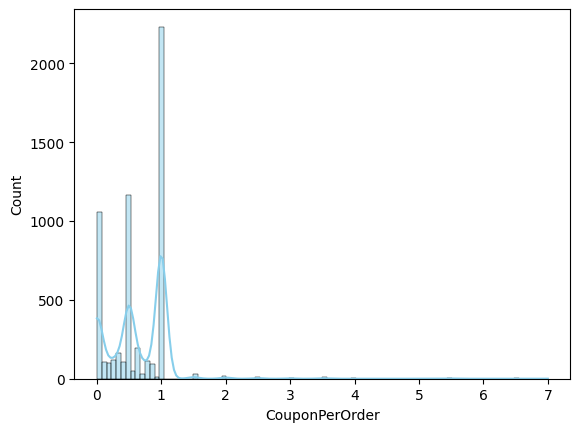

In [ ]:
sns.histplot(data['CouponPerOrder'], kde=True,color='skyblue')
plt.show()

In [ ]:
missing_percent_CouponPerOrder = data['CouponPerOrder'].isnull().mean() * 100
print(f"Percentage of missing values in CouponPerOrder: {missing_percent_CouponPerOrder:.2f}%")

Percentage of missing values in CouponPerOrder: 0.00%


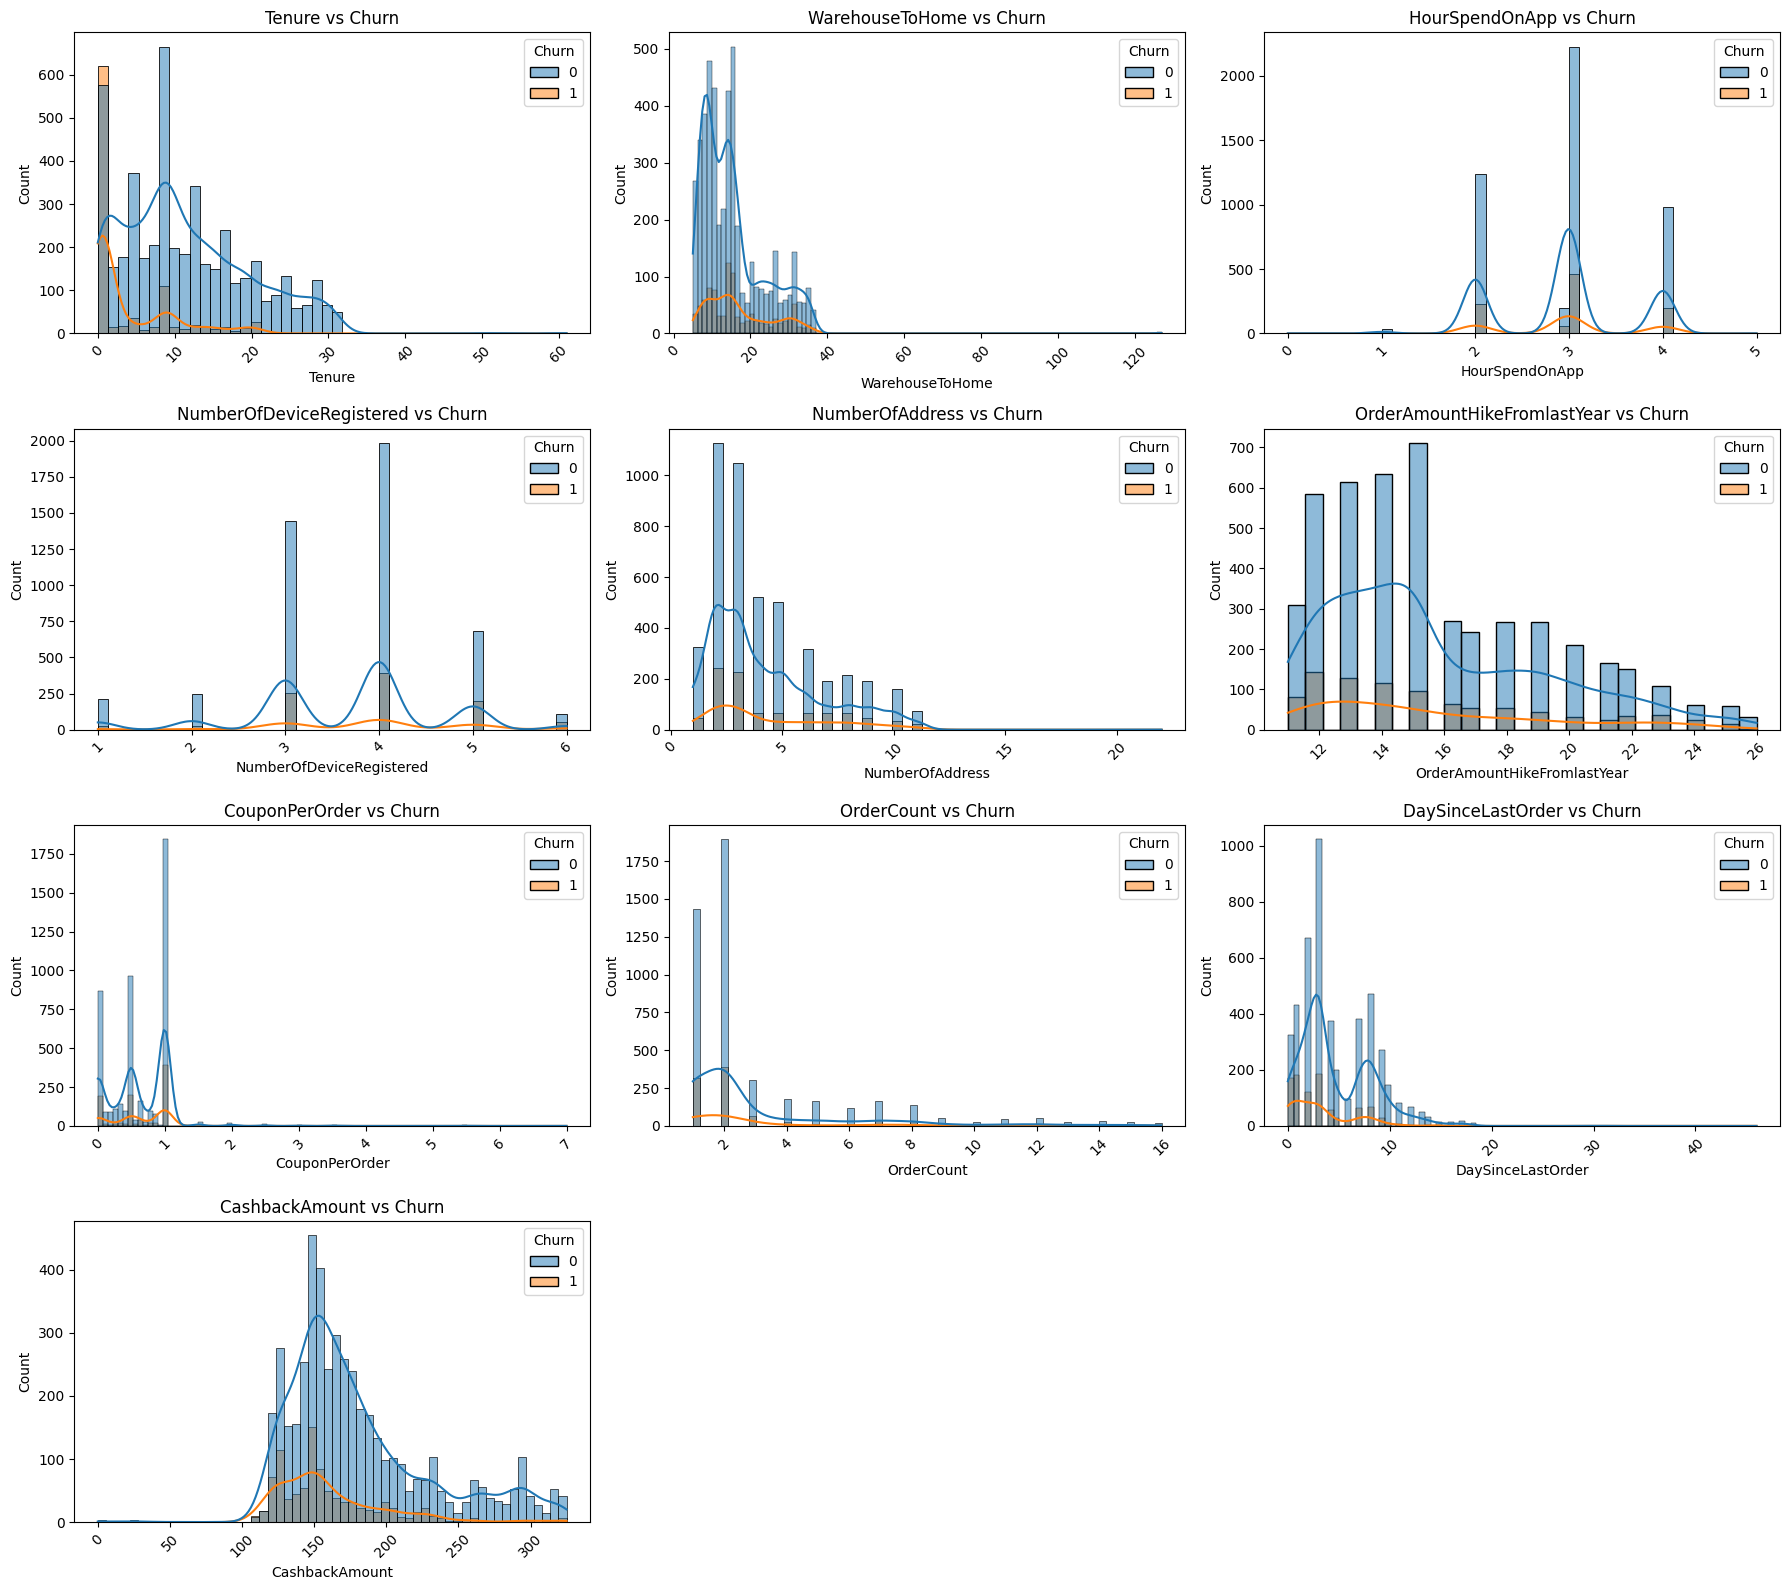

In [ ]:
import math

num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'NumberOfAddress', 'OrderAmountHikeFromlastYear',
            'CouponPerOrder', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

# Grid setup: 3 columns per row
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, hue='Churn', ax=axes[i], kde=True)  # Changed to histplot for numerical data
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

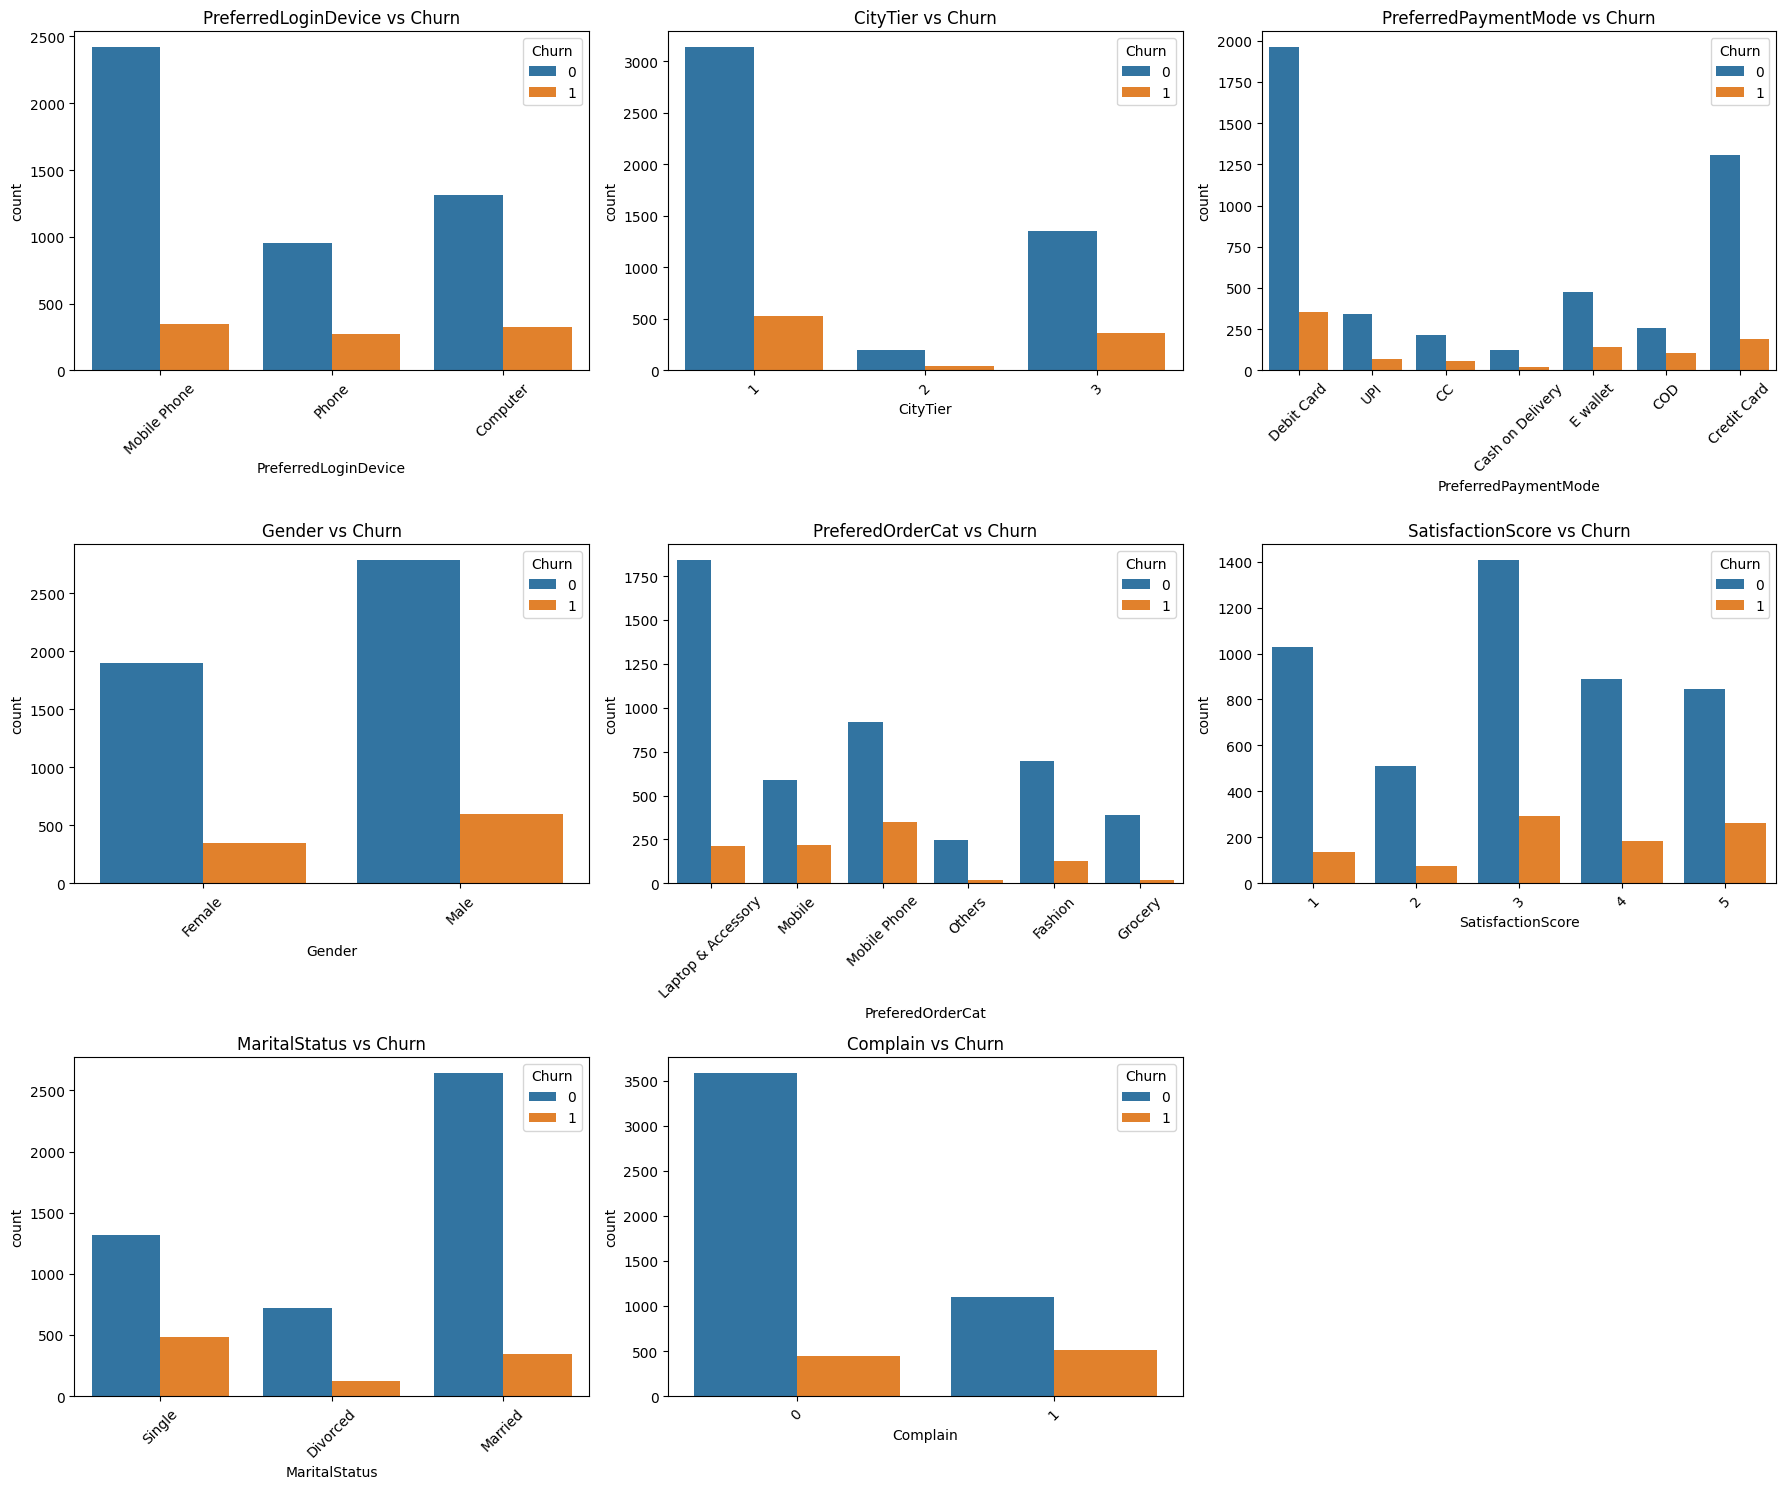

In [ ]:
cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'SatisfactionScore',
            'MaritalStatus', 'Complain']

# Calculate number of rows needed (ceiling of number of columns / 3)
n_rows = (len(cat_cols) + 2) // 3
fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=data, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
X = data.drop(columns=['Churn', 'CustomerID', 'CouponUsed'])
y = data['Churn']
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True) #One Hot Encoding
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])
X = X_encoded

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier


log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}
probs = {
    "Logistic Regression": log_model.predict_proba(X_test)[:, 1],
    "Decision Tree": tree_model.predict_proba(X_test)[:, 1],
    "Random Forest": rf_model.predict_proba(X_test)[:, 1],
    "XGBoost": xgb_model.predict_proba(X_test)[:, 1]
}

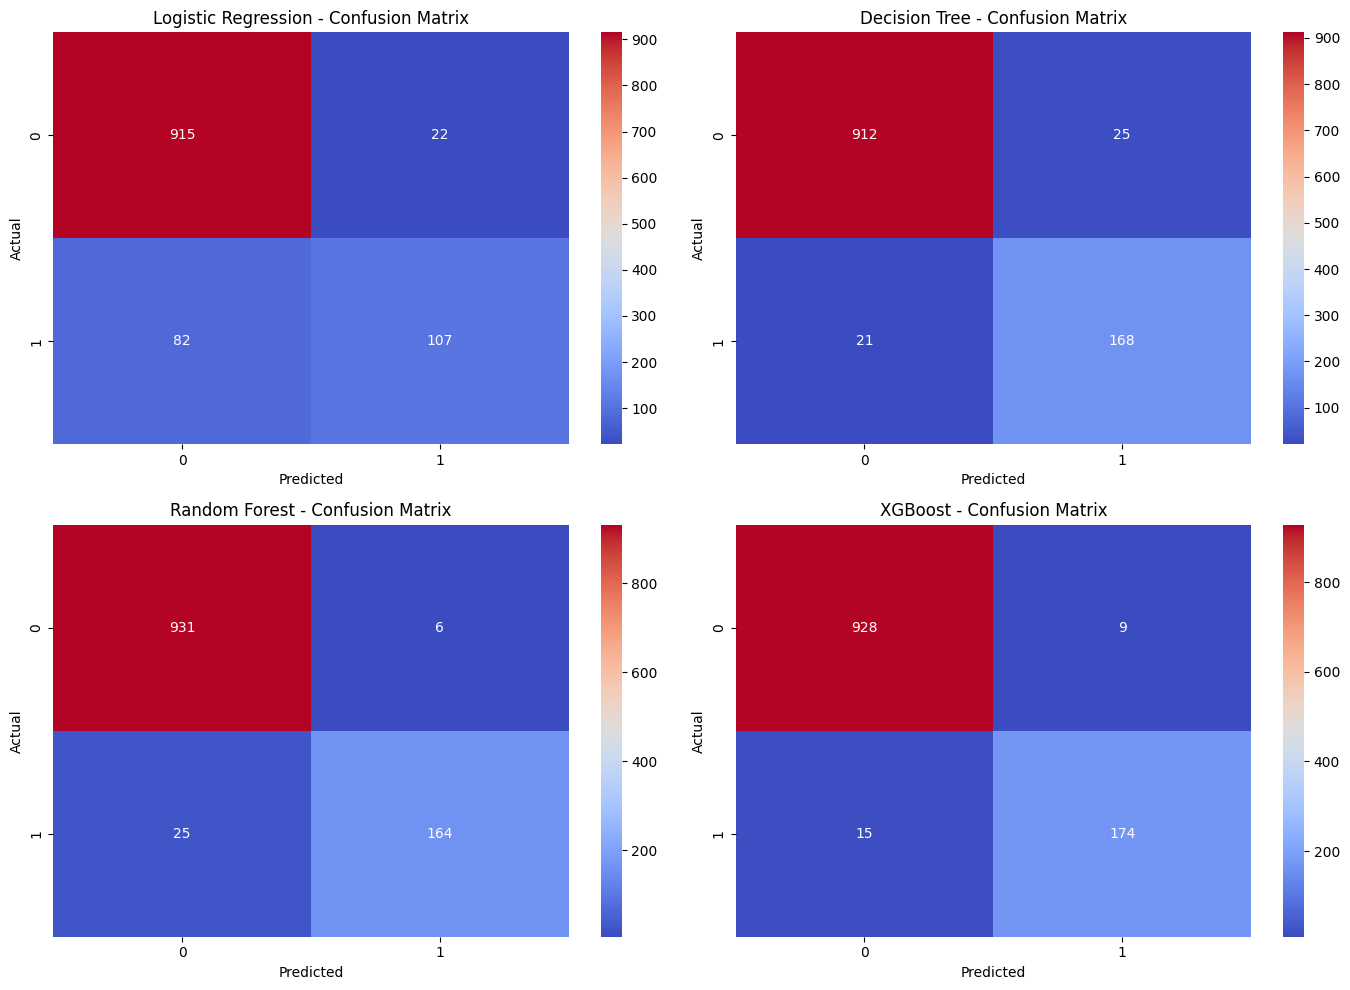

In [ ]:
plt.figure(figsize=(14, 10))

for i, (name, y_pred) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

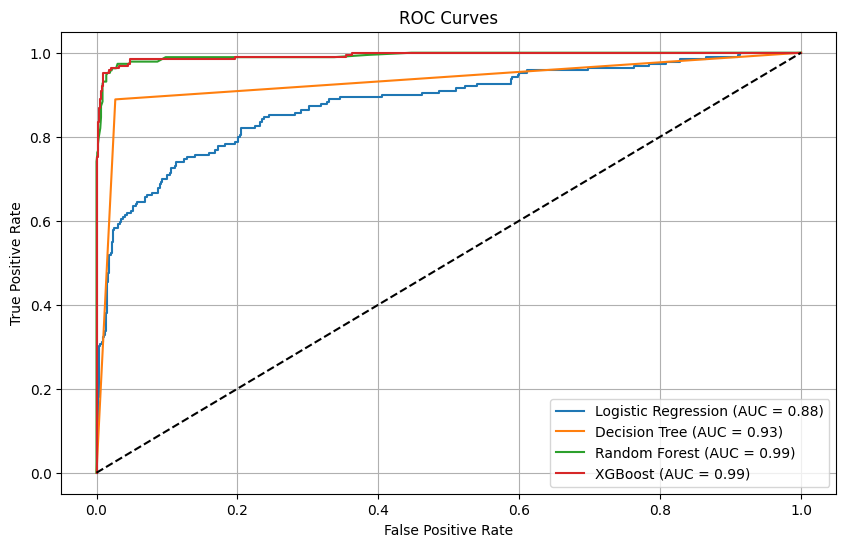

In [ ]:
plt.figure(figsize=(10, 6))

for name, prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
metrics_df = []

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, probs[name])

    metrics_df.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

metrics_df = pd.DataFrame(metrics_df)
print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.907638   0.829457  0.566138  0.672956  0.879391
1        Decision Tree  0.959147   0.870466  0.888889  0.879581  0.931104
2        Random Forest  0.972469   0.964706  0.867725  0.913649  0.992843
3              XGBoost  0.978686   0.950820  0.920635  0.935484  0.992665


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBClassifier()

# Define the parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5,8,14,17,20,25],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.3, 0.4, 0.6, 0.7],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_lambda': [0.01,0.1,1,1.5,3]
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',
    cv=5,
)

# Fit the search to your data
random_search.fit(X_train, y_train)

# Best model
best_xgb = random_search.best_estimator_

# Predict and evaluate
y_pred = best_xgb.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Tuned F1 Score: {f1}")

Best Parameters: {'subsample': 0.7, 'reg_lambda': 0.1, 'n_estimators': 400, 'max_depth': 14, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Tuned F1 Score: 0.9473684210526315


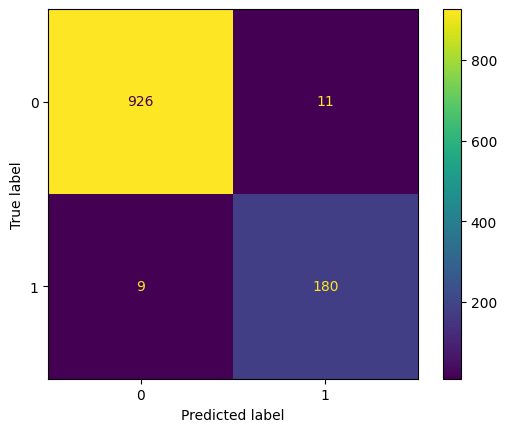

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_proba = best_xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")
print(f"ROC-AUC Score: {auc}")

Accuracy: 0.9822380106571936
Precision: 0.9424083769633508
Recall: 0.9523809523809523
F1-Score: 0.9473684210526315
ROC-AUC Score: 0.9926818112517153


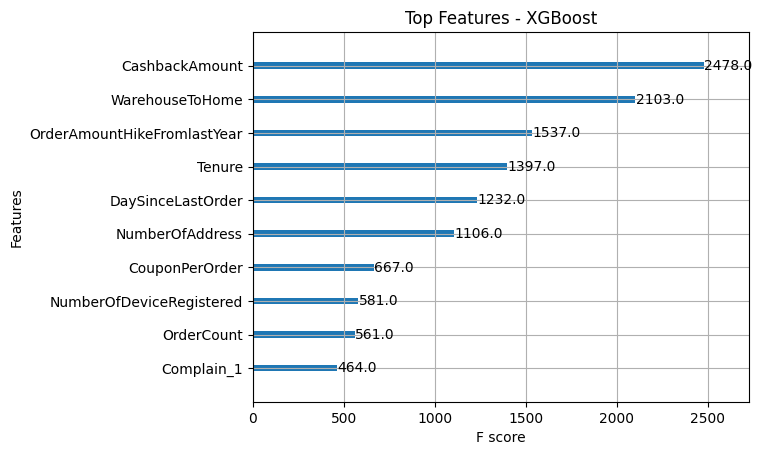

In [ ]:
from xgboost import plot_importance
plot_importance(best_xgb, max_num_features=10)
plt.title("Top Features - XGBoost")
plt.show()

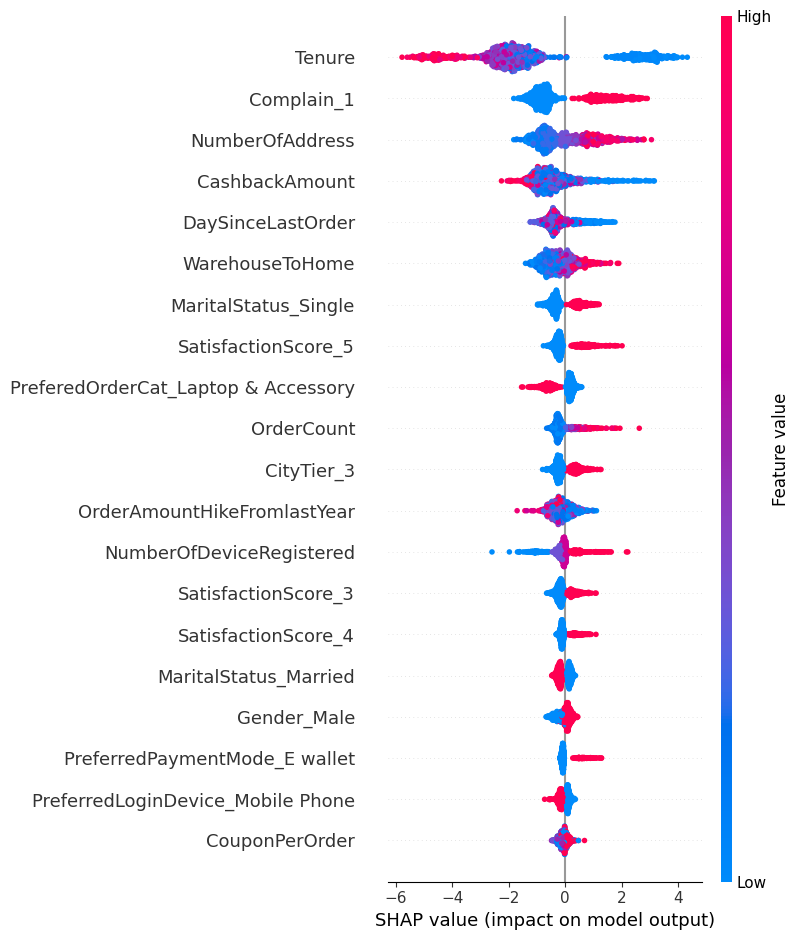

In [ ]:
import shap
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

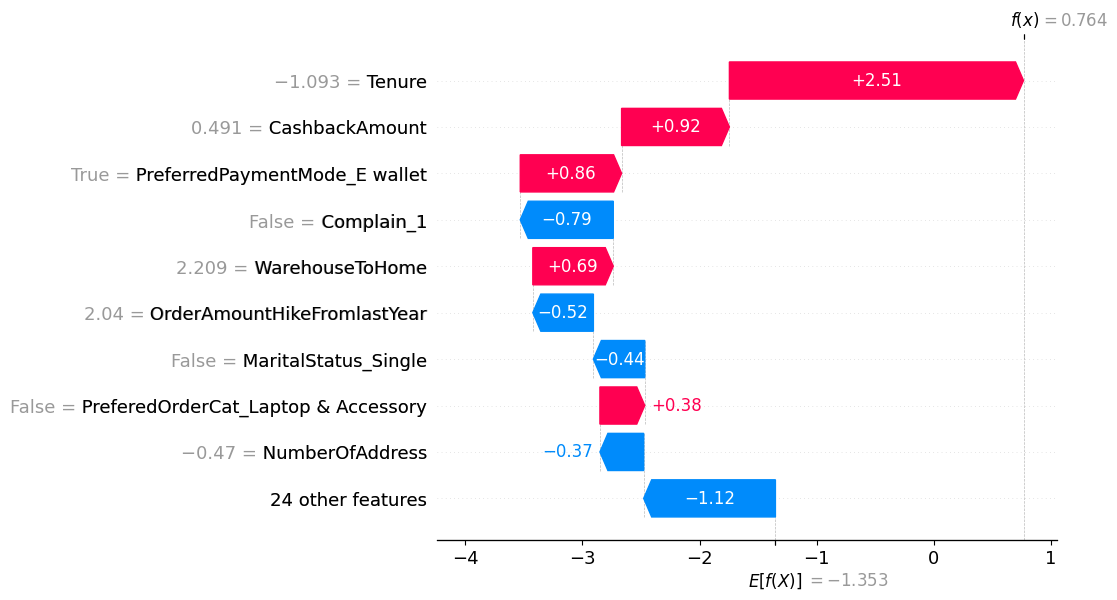

In [ ]:
shap.plots.waterfall(shap_values[3])

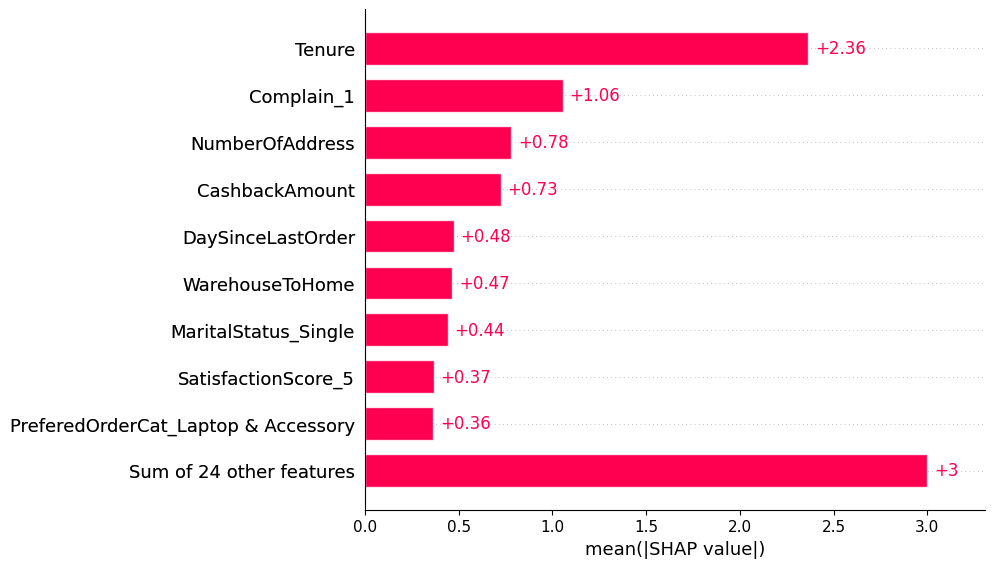

In [ ]:
shap.plots.bar(shap_values)  # Ranked bar chart of average impact